# Mathematical Physics: Heat Equation Diffusivity Inference

Infer thermal diffusivity from sparse temperature snapshots of a one-dimensional heat equation using quantum kernel regression and quantum Gaussian-process regression.

## Problem, Variables, and Quantum Advantage Context

**Physics problem.** Estimate the thermal diffusivity in a rod from a few noisy temperature measurements after diffusion.

**Explicit variables.** `alpha` is the target diffusivity, `sensor_positions` are measurement locations, and `qgpr_alpha_pred` contains quantum-GPR diffusivity estimates.

**Quantum advantage context.** Quantum feature maps provide nonlinear covariance functions for inverse PDE problems where parameters are encoded indirectly in field snapshots. The notebook compares quantum kernel models with ridge regression.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "real_examples":
    repo_root = repo_root.parents[1]
elif repo_root.name == "notebooks":
    repo_root = repo_root.parent

package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from qml import (
    QuantumGaussianProcessRegressor,
    QuantumKernel,
    QuantumKernelClassifier,
    QuantumKernelPCA,
    QuantumKernelRegressor,
    QuantumOneClassClassifier,
    QuantumReservoirClassifier,
    QuantumReservoirFeatures,
    QuantumReservoirRegressor,
    TrainableQuantumKernelRegressor,
)
from qml.reporting import print_section


## Domain simulator

The notebook solves a compact analytic heat-equation surrogate: an initial sine mode decays as `exp(-alpha*pi^2*t)` along the rod.

In [2]:
def heat_snapshot(alpha, sensor_positions, *, time=0.65):
    fundamental = np.sin(np.pi * sensor_positions) * np.exp(-alpha * np.pi**2 * time)
    harmonic = 0.35 * np.sin(2.0 * np.pi * sensor_positions) * np.exp(-4.0 * alpha * np.pi**2 * time)
    return fundamental + harmonic

rng = np.random.default_rng(801)
n_samples = 42
sensor_positions = np.asarray([0.15, 0.32, 0.50, 0.68, 0.85])
alpha = rng.uniform(0.025, 0.18, size=n_samples)
temperature = np.asarray([heat_snapshot(a, sensor_positions) for a in alpha])
temperature += rng.normal(0.0, 0.008, size=temperature.shape)

x_train, x_test, alpha_train, alpha_test = train_test_split(
    temperature, alpha, test_size=0.3, random_state=801
)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(alpha_train.reshape(-1, 1)).ravel()
y_test = y_scaler.transform(alpha_test.reshape(-1, 1)).ravel()

print_section(
    "Dataset",
    [
        ("Problem", "heat equation diffusivity inference"),
        ("Samples", n_samples),
        ("Features", [f"T(x={x:.2f})" for x in sensor_positions]),
        ("Target", "thermal diffusivity alpha"),
    ],
)


Dataset
+----------+---------------------------------------------------------+
| Metric   | Value                                                   |
+----------+---------------------------------------------------------+
| Problem  | heat equation diffusivity inference                     |
| Samples  | 42                                                      |
| Features | [T(x=0.15), T(x=0.32), T(x=0.50), T(x=0.68), T(x=0.85)] |
| Target   | thermal diffusivity alpha                               |
+----------+---------------------------------------------------------+



## System visualization

A direct plot of the simulated physical or mathematical system before fitting any machine-learning model.

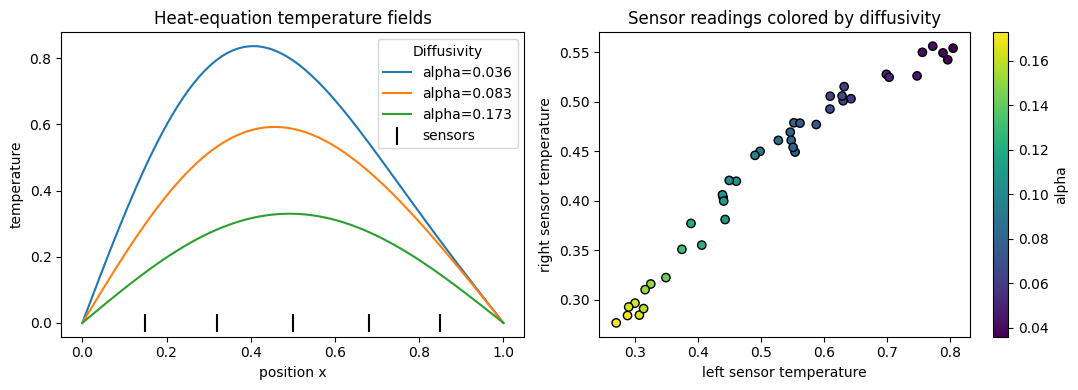

In [3]:
position_grid = np.linspace(0.0, 1.0, 160)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for a in [alpha.min(), np.median(alpha), alpha.max()]:
    axes[0].plot(position_grid, heat_snapshot(a, position_grid), label=f"alpha={a:.3f}")
axes[0].scatter(sensor_positions, np.zeros_like(sensor_positions), marker="|", s=180, color="black", label="sensors")
axes[0].set_title("Heat-equation temperature fields")
axes[0].set_xlabel("position x")
axes[0].set_ylabel("temperature")
axes[0].legend(title="Diffusivity")
scatter = axes[1].scatter(temperature[:, 1], temperature[:, 3], c=alpha, cmap="viridis", edgecolor="black")
axes[1].set_title("Sensor readings colored by diffusivity")
axes[1].set_xlabel("left sensor temperature")
axes[1].set_ylabel("right sensor temperature")
fig.colorbar(scatter, ax=axes[1], label="alpha")
plt.tight_layout()
plt.show()


## Package-client inverse models

In [4]:
qgpr = QuantumGaussianProcessRegressor(QuantumKernel(embedding="iqp", seed=801), alpha=2e-3)
qgpr.fit(x_train, y_train)
qgpr_alpha_pred = y_scaler.inverse_transform(qgpr.predict(x_test).reshape(-1, 1)).ravel()

qkr = QuantumKernelRegressor(QuantumKernel(embedding="zz", seed=802), alpha=5e-3)
qkr.fit(x_train, y_train)
qkr_alpha_pred = y_scaler.inverse_transform(qkr.predict(x_test).reshape(-1, 1)).ravel()

ridge = Ridge(alpha=1e-2)
ridge.fit(x_train, y_train)
ridge_alpha_pred = y_scaler.inverse_transform(ridge.predict(x_test).reshape(-1, 1)).ravel()

results = {
    "quantum_gpr_alpha_mae": mean_absolute_error(alpha_test, qgpr_alpha_pred),
    "quantum_kernel_alpha_mae": mean_absolute_error(alpha_test, qkr_alpha_pred),
    "ridge_alpha_mae": mean_absolute_error(alpha_test, ridge_alpha_pred),
    "quantum_gpr_alpha_mse": mean_squared_error(alpha_test, qgpr_alpha_pred),
}

print_section(
    "Results",
    [
        ("Quantum GPR alpha MAE", results["quantum_gpr_alpha_mae"]),
        ("Quantum kernel alpha MAE", results["quantum_kernel_alpha_mae"]),
        ("Ridge alpha MAE", results["ridge_alpha_mae"]),
    ],
)


Results
+--------------------------+------------+
| Metric                   | Value      |
+--------------------------+------------+
| Quantum GPR alpha MAE    | 0.00397051 |
| Quantum kernel alpha MAE | 0.0035871  |
| Ridge alpha MAE          | 0.00231943 |
+--------------------------+------------+



## Plots

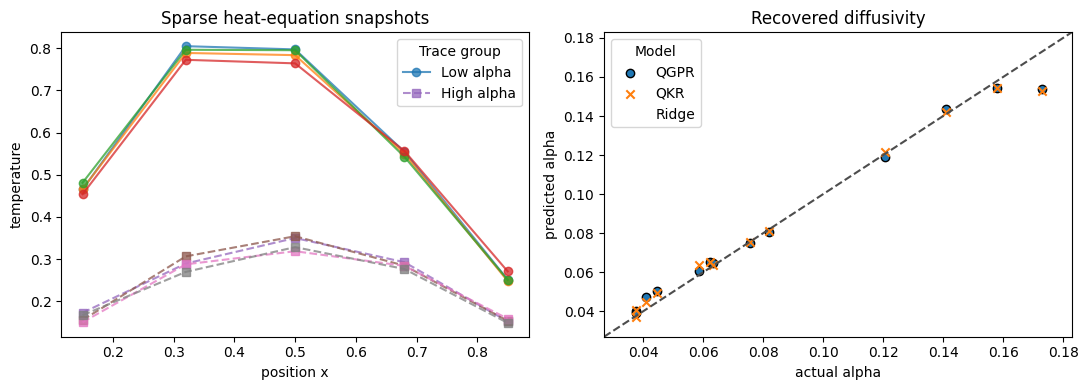

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
low_alpha = np.argsort(alpha)[:4]
high_alpha = np.argsort(alpha)[-4:]
for pos, idx in enumerate(low_alpha):
    axes[0].plot(sensor_positions, temperature[idx], "o-", alpha=0.75, label="Low alpha" if pos == 0 else None)
for pos, idx in enumerate(high_alpha):
    axes[0].plot(sensor_positions, temperature[idx], "s--", alpha=0.75, label="High alpha" if pos == 0 else None)
axes[0].set_title("Sparse heat-equation snapshots")
axes[0].set_xlabel("position x")
axes[0].set_ylabel("temperature")
axes[0].legend(title="Trace group")

low = min(alpha_test.min(), qgpr_alpha_pred.min(), qkr_alpha_pred.min(), ridge_alpha_pred.min()) - 0.01
high = max(alpha_test.max(), qgpr_alpha_pred.max(), qkr_alpha_pred.max(), ridge_alpha_pred.max()) + 0.01
axes[1].scatter(alpha_test, qgpr_alpha_pred, label="QGPR", edgecolor="black")
axes[1].scatter(alpha_test, qkr_alpha_pred, marker="x", label="QKR")
axes[1].scatter(alpha_test, ridge_alpha_pred, marker="s", facecolors="none", label="Ridge")
axes[1].plot([low, high], [low, high], "--", color="0.3")
axes[1].set_xlim(low, high)
axes[1].set_ylim(low, high)
axes[1].set_title("Recovered diffusivity")
axes[1].set_xlabel("actual alpha")
axes[1].set_ylabel("predicted alpha")
axes[1].legend(title="Model")
plt.tight_layout()
plt.show()


## Validation block

In [6]:
validation = {
    "dataset": {
        "problem": "heat_equation_diffusivity_inference",
        "n_train": int(len(alpha_train)),
        "n_test": int(len(alpha_test)),
        "feature_count": int(x_train.shape[1]),
    },
    "results": results,
    "sample_predictions": [
        {"actual_alpha": float(a), "quantum_gpr_alpha": float(g), "quantum_kernel_alpha": float(k)}
        for a, g, k in zip(alpha_test[:6], qgpr_alpha_pred[:6], qkr_alpha_pred[:6])
    ],
    "passed": bool(
        np.isfinite(qgpr_alpha_pred).all()
        and np.isfinite(qkr_alpha_pred).all()
        and results["quantum_gpr_alpha_mae"] < 0.08
    ),
}

print("Validation")
print_section("Dataset", validation["dataset"].items())
print_section("Results", validation["results"].items())
print_section("Sample predictions", validation["sample_predictions"][:5])
print_section("Passed", [("passed", validation["passed"])])


Validation
Dataset
+---------------+-------------------------------------+
| Metric        | Value                               |
+---------------+-------------------------------------+
| problem       | heat_equation_diffusivity_inference |
| n_train       | 29                                  |
| n_test        | 13                                  |
| feature_count | 5                                   |
+---------------+-------------------------------------+

Results
+--------------------------+-------------+
| Metric                   | Value       |
+--------------------------+-------------+
| quantum_gpr_alpha_mae    | 0.00397051  |
| quantum_kernel_alpha_mae | 0.0035871   |
| ridge_alpha_mae          | 0.00231943  |
| quantum_gpr_alpha_mse    | 3.74068e-05 |
+--------------------------+-------------+

Sample predictions
+--------------+-------------------+----------------------+
| actual_alpha | quantum_gpr_alpha | quantum_kernel_alpha |
+--------------+-------------------+----